In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configure Plotting Style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Define Paths
# We look one folder up (..) then into Data
data_dir = os.path.join("..", "Data")

print(f"Reading data from: {os.path.abspath(data_dir)}")

Reading data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data


In [3]:
# 1. Load Population Means (Mu)
# -----------------------------
try:
    df_mu = pd.read_csv(os.path.join(data_dir, "R_mu_draws.csv"))
    mu_samples = df_mu.values
    print(f"Loaded Mu Draws: {mu_samples.shape} (Draws, Params)")
except FileNotFoundError:
    print("Error: 'R_mu_draws.csv' not found.")

# 2. Load Individual Betas (Full Distribution)
# --------------------------------------------
try:
    df_beta_raw = pd.read_csv(os.path.join(data_dir, "R_beta_draws.csv"))
    
    # Metadata
    n_draws = df_beta_raw['Draw_ID'].max()
    n_units = df_beta_raw['Unit_ID'].max()
    
    # Drop ID columns to get values only
    # Ensure sorted by Draw, then Unit to match reshaping logic
    df_beta_sorted = df_beta_raw.sort_values(['Draw_ID', 'Unit_ID'])
    beta_values = df_beta_sorted.drop(columns=['Unit_ID', 'Draw_ID']).values
    n_params = beta_values.shape[1]

    # Reshape to (Draws, Units, Params)
    beta_samples = beta_values.reshape(n_draws, n_units, n_params)
    
    print(f"Loaded Beta Draws: {beta_samples.shape} (Draws, Units, Params)")
    
    # Calculate Posterior Means per Person (used for predictions)
    beta_means = beta_samples.mean(axis=0) # Shape: (332, 10)

except FileNotFoundError:
    print("Error: 'R_beta_draws.csv' not found.")
    
# Parameter Names
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

Error: 'R_mu_draws.csv' not found.
Error: 'R_beta_draws.csv' not found.


In [4]:
# Calculate Summary Stats
mu_mean = np.mean(mu_samples, axis=0)
mu_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_upper = np.percentile(mu_samples, 97.5, axis=0)

# Create DataFrame
df_plot_mu = pd.DataFrame({
    'Parameter': param_names,
    'Mean': mu_mean,
    'Lower': mu_lower,
    'Upper': mu_upper
})

# Plot
plt.figure(figsize=(10, 6))
# Reverse order for top-to-bottom plotting
df_rev = df_plot_mu.iloc[::-1]

plt.errorbar(
    x=df_rev['Mean'], 
    y=df_rev['Parameter'], 
    xerr=[df_rev['Mean'] - df_rev['Lower'], df_rev['Upper'] - df_rev['Mean']],
    fmt='o', color='#2E86C1', ecolor='#2E86C1', capsize=4, markersize=8
)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.6)
plt.title("R Model: Population Means (95% CI)")
plt.xlabel("Utility")
plt.show()

NameError: name 'mu_samples' is not defined

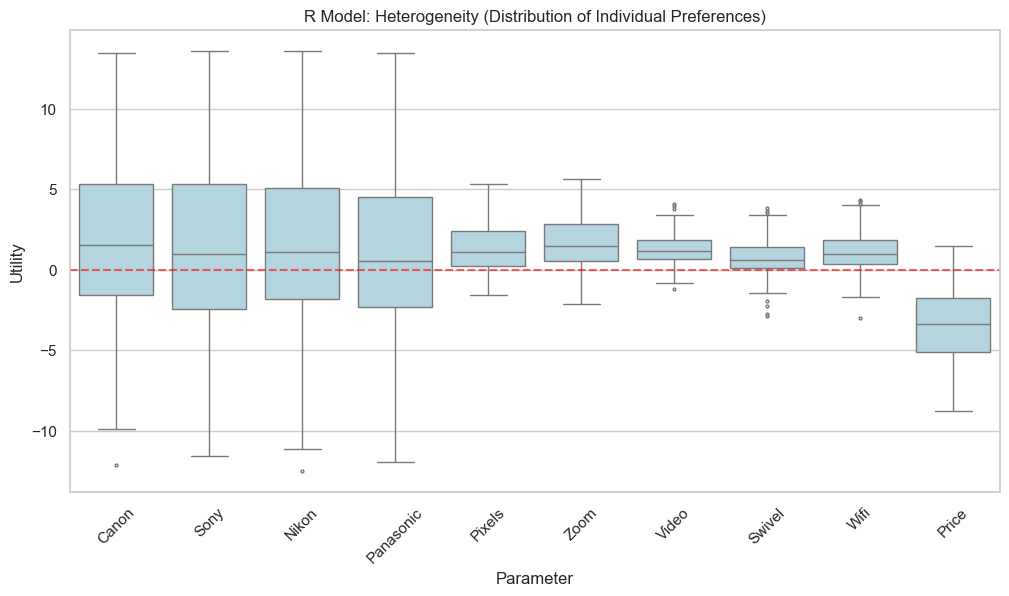

In [ ]:
# Create DataFrame of Individual Means
df_beta_means = pd.DataFrame(beta_means, columns=param_names)

# Melt for Boxplot
df_melted = df_beta_means.melt(var_name='Parameter', value_name='Utility')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Parameter', y='Utility', color='lightblue', fliersize=2)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.title("R Model: Heterogeneity (Distribution of Individual Preferences)")
plt.xticks(rotation=45)
plt.show()

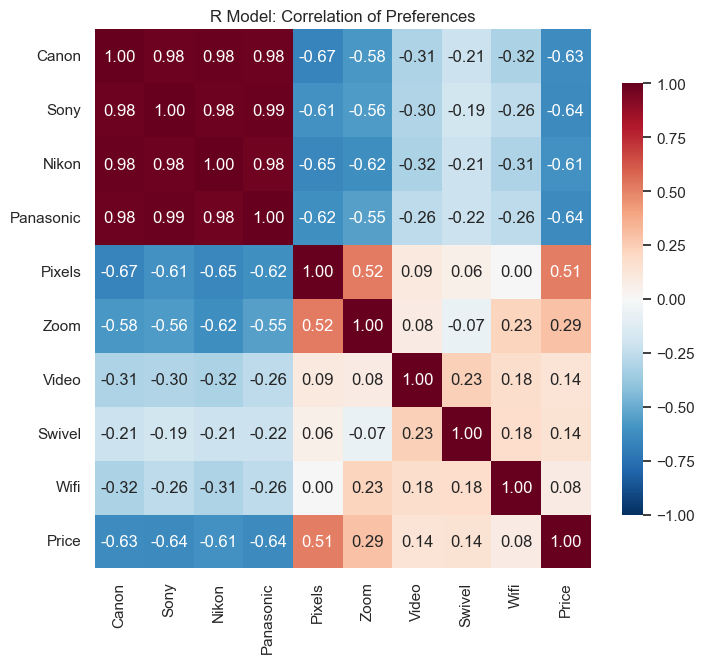

In [ ]:
corr_matrix = df_beta_means.corr()

plt.figure(figsize=(8, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0, 
    vmin=-1, vmax=1,
    cbar_kws={"shrink": .8}
)
plt.title("R Model: Correlation of Preferences")
plt.show()

In [ ]:
# 1. Load Original Data
with open(os.path.join(data_dir, "camera_data.json"), 'r') as f:
    raw_data = json.load(f)

# 2. Extract X and y in format suitable for vectorized calculation
X_list = []
y_list = []
unit_indices = []

n_alts = 5

for i, respondent in enumerate(raw_data):
    X_raw = np.array(respondent['X'])
    y_raw = np.array(respondent['y'])
    
    # Reshape X: (Obs, Alts, Params)
    X_reshaped = X_raw.reshape((len(y_raw), n_alts, X_raw.shape[1]))
    # Adjust Y to 0-based index
    y_adjusted = y_raw - 1
    
    X_list.append(X_reshaped)
    y_list.append(y_adjusted)
    unit_indices.extend([i] * len(y_raw))

X_all = np.concatenate(X_list, axis=0)      # (Total_Obs, 5, 10)
y_all = np.concatenate(y_list, axis=0)      # (Total_Obs,)
unit_idx_all = np.array(unit_indices)       # (Total_Obs,)

# 3. Calculate Hit Rate
# Expand Beta Means to Observation Level
beta_expanded = beta_means[unit_idx_all]    # (Total_Obs, 10)

# Calculate Utility: (Total_Obs, 5_alts)
utilities = np.einsum("nij,nj->ni", X_all, beta_expanded)

# Predict
predictions = np.argmax(utilities, axis=1)

# Score
hits = np.sum(predictions == y_all)
total = len(y_all)
hit_rate = (hits / total) * 100

print("========================================")
print(f"R MODEL PREDICTIVE PERFORMANCE")
print("========================================")
print(f"Total Observations : {total}")
print(f"Correct Hits       : {hits}")
print(f"Hit Rate           : {hit_rate:.2f}%")
print("========================================")

R MODEL PREDICTIVE PERFORMANCE
Total Observations : 5312
Correct Hits       : 4577
Hit Rate           : 86.16%


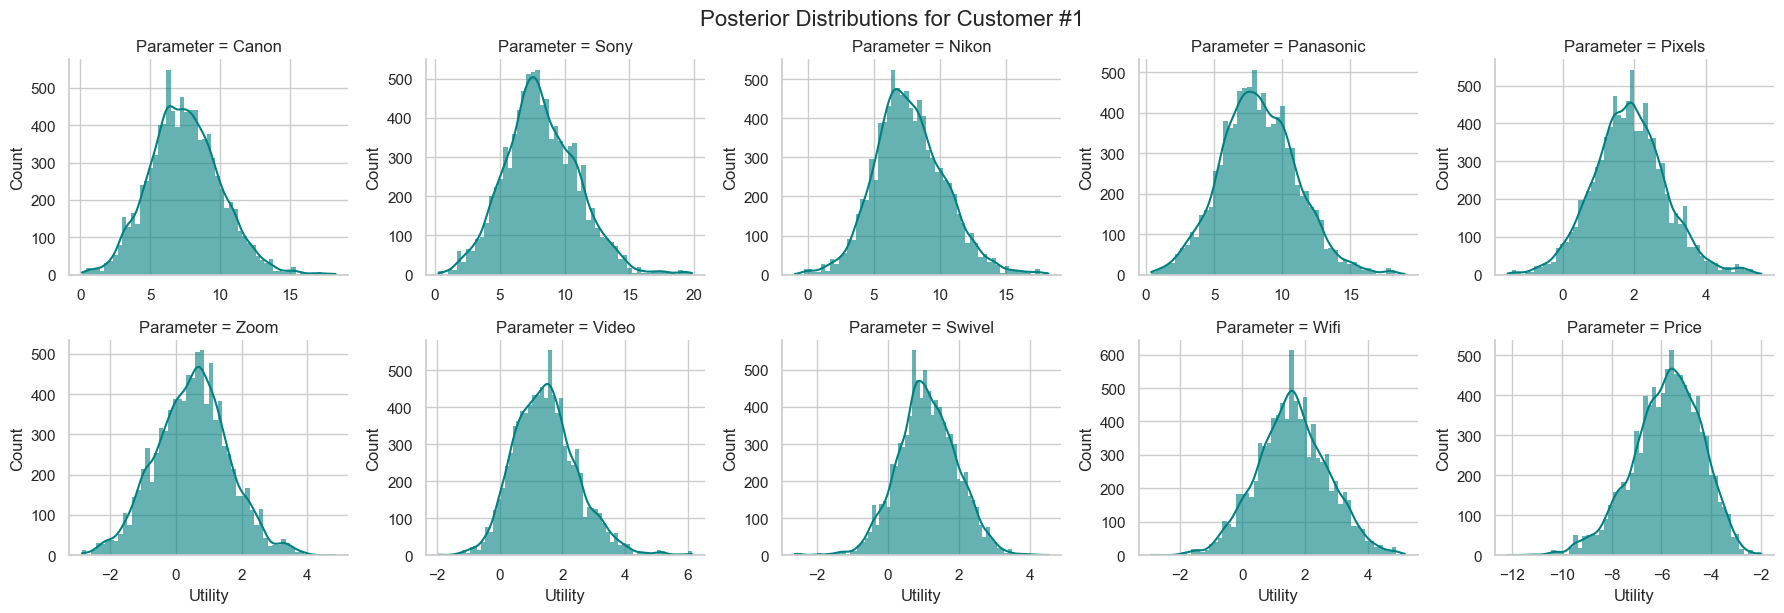

In [ ]:
# 1. Select Data for First Customer (Index 0)
# -------------------------------------------
unit_idx = 0
# Slice: All draws, Unit 0, All parameters
# Shape becomes: (2000 Draws, 10 Params)
customer_0_betas = beta_samples[:, unit_idx, :]

# 2. Prepare DataFrame
# --------------------
df_cust0 = pd.DataFrame(customer_0_betas, columns=param_names)

# Melt to long format for easy plotting with Seaborn
df_melted = df_cust0.melt(var_name="Parameter", value_name="Utility")

# 3. Plot Distributions (Facet Grid)
# ----------------------------------
g = sns.FacetGrid(
    df_melted, 
    col="Parameter", 
    col_wrap=5,      # 5 plots per row
    sharex=False,    # Let x-axis scales vary per parameter
    sharey=False,    # Let y-axis scales vary
    height=3, 
    aspect=1.2
)

# Add Histograms with Kernel Density Estimate (KDE)
g.map(sns.histplot, "Utility", kde=True, color="teal", alpha=0.6, linewidth=0)

g.fig.suptitle(f"Posterior Distributions for Customer #{unit_idx+1}", y=1.02, fontsize=16)
plt.show()